# Build a Basic ChatBot (Graph API)

In [17]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [18]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [19]:
graph_builder

In [20]:
import os
from dotenv import load_dotenv
load_dotenv()

import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="llama-3.3-70b-versatile")

In [22]:
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001645A64FAC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001645A64E050>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [23]:
def chatbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}

In [24]:
graph_builder = StateGraph(State)

## adding node
graph_builder.add_node("llmchatbot", chatbot)

## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

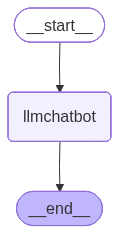

In [25]:
## visualize graph
from IPython.display import Image, display


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [26]:
resp = graph.invoke({"messages": "Hi"})

In [27]:
resp["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [28]:
for event in graph.stream({"messages": "Hi, How are you?"}):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content="I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions you might have. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 41, 'total_tokens': 98, 'completion_time': 0.106781863, 'completion_tokens_details': None, 'prompt_time': 0.014181664, 'prompt_tokens_details': None, 'queue_time': 2.861295053, 'total_time': 0.120963527}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eac58-c0fb-7cc3-8a41-191df6896464-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 57, 'total_tokens': 98})]}


In [80]:
from langchain_tavily import TavilySearch
from langchain.tools import tool

tool1 = TavilySearch(max_results=2)
resp = tool1.invoke("What is langgraph?")

resp['results']

[{'url': 'https://www.ibm.com/think/topics/langgraph',
  'title': 'What is LangGraph? - IBM',
  'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigator charts out the optimal routes between points on the “Super-Map,” all of which are created by “The 

In [81]:
### Custom Function
@tool
def multiply(a:int, b:int) -> int:
    """Multipy a and b

    Args:
    a (int): first int
    b (int): second int

    Returns:
        int: output int
    """
    return a * b

In [82]:
tools = [tool1, multiply]
llm_with_tools = model.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001645A64FAC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001645A64E050>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

In [83]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [84]:
### StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

## adding node
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))
## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_conditional_edges(
    "llmchatbot",
    tools_condition
) 
graph_builder.add_edge("tools", END)

## compile the graph
graph = graph_builder.compile()

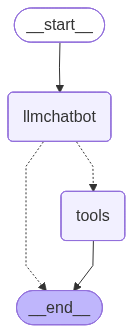

In [85]:
## visualize graph
from IPython.display import Image, display


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [86]:
resp = graph.invoke({"messages": "What is the recent ai news"})

resp['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://gizmodo.com/big-tech-is-quietly-admitting-that-if-it-wants-to-sell-people-on-ai-it-better-be-cheap-2000768710", "title": "Big Tech Is Quietly Admitting That If It Wants to Sell People on AI, It Better Be Cheap - Gizmodo", "score": 0.657561, "published_date": "Mon, 08 Jun 2026 15:15:54 GMT", "content": "# Big Tech Is Quietly Admitting That If It Wants to Sell People on AI, It Better Be Cheap. In recent weeks, big tech companies have been forced to admit that spending on tokens—the basic unit of measurement for AI usage—has gotten out of control. Amazon had to shut down an in-house competition to use as many tokens as possible at work, telling employees, “Please don’t use AI just for the sake of using AI,” according to *Business Insider*; Uber has reportedly capped employee spending on tokens to $1,500 per month after the company exhausted its annual AI budget earlier this

In [87]:
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8etdc324g)
 Call ID: 8etdc324g
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://gizmodo.com/big-tech-is-quietly-admitting-that-if-it-wants-to-sell-people-on-ai-it-better-be-cheap-2000768710", "title": "Big Tech Is Quietly Admitting That If It Wants to Sell People on AI, It Better Be Cheap - Gizmodo", "score": 0.657561, "published_date": "Mon, 08 Jun 2026 15:15:54 GMT", "content": "# Big Tech Is Quietly Admitting That If It Wants to Sell People on AI, It Better Be Cheap. In recent weeks, big tech companies have been forced to admit that 

In [88]:
resp = graph.invoke({"messages": "What is 2 multiplied by 7"})
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  multiply (yrd5bzcja)
 Call ID: yrd5bzcja
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: multiply

14


In [89]:
resp = graph.invoke({"messages": "What is the recent ai news and the result of 2 multiplied by 7"})
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news and the result of 2 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jhv8cx441)
 Call ID: jhv8cx441
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tipranks.com/news/private-companies/ubeya-highlights-ai-driven-workforce-analytics-capability", "title": "Ubeya Highlights AI-Driven Workforce Analytics Capability - TipRanks", "score": 0.6158511, "published_date": "Wed, 03 Jun 2026 12:04:41 GMT", "content": "# Ubeya Highlights AI-Driven Workforce Analytics Capability. According to a recent LinkedIn post from Ubeya, the company is highlighting a new AI-driven featu

## ReAct Agent

### Act, Observe, Reason

In [99]:
import langgraph
print(langgraph.__version__)

AttributeError: module 'langgraph' has no attribute '__version__'

In [100]:
### StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

graph_builder = StateGraph(State)
memory = MemorySaver()

## adding node
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))
## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_conditional_edges(
    "llmchatbot",
    tools_condition
) 
graph_builder.add_edge("tools", "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile(checkpointer=memory)

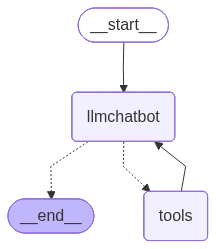

In [91]:
## visualize graph
from IPython.display import Image, display


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [92]:
resp = graph.invoke({"messages": "What is the recent ai news and the result of 2 multiplied by 7"})
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news and the result of 2 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fy8tt850p)
 Call ID: fy8tt850p
  Args:
    query: recent AI news
    topic: news
  multiply (0kb7dtccs)
 Call ID: 0kb7dtccs
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.7783298, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Codex feature that

### Adding Memory in Agentic Graph

In [94]:
resp = graph.invoke({"messages": "Hello my name is Nayan"})
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Nayan
================================== Ai Message ==================================

Hello Nayan, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [95]:
resp = graph.invoke({"messages": "What is my name?"})
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. Our conversation just started, and I don't have the ability to access any personal data about you. If you'd like to share your name, I'd be happy to chat with you!


In [104]:
config = {"configurable": {
    "thread_id": "1"
}}

resp = graph.invoke({"messages": "Hello my name is Nayan"}, config=config)
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Nayan
================================== Ai Message ==================================

Hello Nayan, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [105]:
resp = graph.invoke({"messages": "What is my name?"}, config=config)
for m in resp["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Nayan
================================== Ai Message ==================================

Hello Nayan, it's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Nayan.


### Streaming

In [106]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [108]:
def superbot(state: State):
    return {"messages": [model.invoke(state['messages'])]}

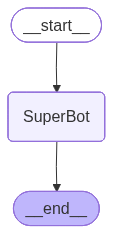

In [113]:
graph = StateGraph(State)

graph.add_node("SuperBot", superbot)

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image, display
try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception:
    pass